# Hito 1: Spotify Playlists

**Pontificia Universidad Catolica de Chile**  
**Curso:** IIC3633 Sistemas Recomendadores  
**Periodo:** Marzo-Julio 2026  
**Integrantes:** Agustin Llambias, Amaya Quero, Larry Uribe

Este notebook contiene el analisis y los modelos baseline del Hito 1 usando el dataset Spotify Playlists de Kaggle. Para esta etapa se utiliza una muestra deterministica del 30% de playlists, preservando playlists completas.

In [1]:
from pathlib import Path
from collections import Counter, defaultdict
import math
import random
import re

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

DATA_PATH = Path("data/spotify_dataset.csv")
SAMPLE_PERCENT = 30
TOP_K = 10
RANDOM_SEED = 42

print("Dataset existe:", DATA_PATH.exists())
print("Ruta:", DATA_PATH.resolve())
print("Tamano GB:", round(DATA_PATH.stat().st_size / 1024**3, 2))

Dataset existe: True
Ruta: C:\RecSys\Proyecto-RecSys-2026-1\data\spotify_dataset.csv
Tamano GB: 1.1


## 1. Estadisticas globales con DuckDB

DuckDB permite consultar el CSV completo sin cargarlo primero como un unico DataFrame de pandas. Esto se usa para obtener estadisticas globales del archivo de 12.2M filas.

In [2]:
con = duckdb.connect()
base_csv = """
read_csv(
  'data/spotify_dataset.csv',
  header=true,
  ignore_errors=true,
  all_varchar=true,
  normalize_names=true
)
"""

full_stats_query = f"""
WITH data AS (
  SELECT
    user_id,
    artistname,
    trackname,
    playlistname,
    artistname || ' - ' || trackname AS item_id,
    user_id || '||' || playlistname AS playlist_id
  FROM {base_csv}
  WHERE user_id IS NOT NULL
    AND artistname IS NOT NULL
    AND trackname IS NOT NULL
    AND playlistname IS NOT NULL
)
SELECT
  count(*) AS registros,
  count(DISTINCT user_id) AS usuarios,
  count(DISTINCT artistname) AS artistas,
  count(DISTINCT trackname) AS tracks,
  count(DISTINCT item_id) AS items_artista_track,
  count(DISTINCT playlist_id) AS playlists
FROM data
"""
full_stats = con.execute(full_stats_query).fetchdf()
display(full_stats)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,registros,usuarios,artistas,tracks,items_artista_track,playlists
0,12199339,15889,271369,1854175,2614129,225591


## 2. Muestra deterministica del 30%

La muestra se construye por hash de `user_id || playlistname`. Esto preserva playlists completas y hace que la muestra sea reproducible.

In [3]:
sample_query = f"""
WITH data AS (
  SELECT
    user_id,
    artistname,
    trackname,
    playlistname,
    artistname || ' - ' || trackname AS item_id,
    user_id || '||' || playlistname AS playlist_id
  FROM {base_csv}
  WHERE user_id IS NOT NULL
    AND artistname IS NOT NULL
    AND trackname IS NOT NULL
    AND playlistname IS NOT NULL
)
SELECT *
FROM data
WHERE hash(playlist_id) % 100 < {SAMPLE_PERCENT}
"""

music_df = con.execute(sample_query).fetchdf()
print("Filas muestra:", len(music_df))
print("Usuarios muestra:", music_df['user_id'].nunique())
print("Playlists muestra:", music_df['playlist_id'].nunique())
print("Items muestra:", music_df['item_id'].nunique())
display(music_df.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Filas muestra: 3721218


Usuarios muestra: 12745


Playlists muestra: 68012


Items muestra: 1273839


,user_id,artistname,trackname,playlistname,item_id,playlist_id
0,"""9cc0cfd4d7d7885102480dd99e7a90d6""","""Elvis Costello""","""(The Angels Wanna Wear My) Red Shoes""","""HARD ROCK 2010""","""Elvis Costello"" - ""(The Angels Wanna Wear My)...","""9cc0cfd4d7d7885102480dd99e7a90d6""||""HARD ROCK..."
1,"""9cc0cfd4d7d7885102480dd99e7a90d6""","""Tiffany Page""","""7 Years Too Late""","""HARD ROCK 2010""","""Tiffany Page"" - ""7 Years Too Late""","""9cc0cfd4d7d7885102480dd99e7a90d6""||""HARD ROCK..."
2,"""9cc0cfd4d7d7885102480dd99e7a90d6""","""Elvis Costello & The Attractions""","""Accidents Will Happen""","""HARD ROCK 2010""","""Elvis Costello & The Attractions"" - ""Accident...","""9cc0cfd4d7d7885102480dd99e7a90d6""||""HARD ROCK..."
3,"""9cc0cfd4d7d7885102480dd99e7a90d6""","""Elvis Costello""","""Alison""","""HARD ROCK 2010""","""Elvis Costello"" - ""Alison""","""9cc0cfd4d7d7885102480dd99e7a90d6""||""HARD ROCK..."
4,"""9cc0cfd4d7d7885102480dd99e7a90d6""","""Lissie""","""All Be Okay""","""HARD ROCK 2010""","""Lissie"" - ""All Be Okay""","""9cc0cfd4d7d7885102480dd99e7a90d6""||""HARD ROCK..."


## 3. Analisis descriptivo

Se revisa el tamano de playlists, artistas frecuentes y distribucion de popularidad de canciones.

,metrica,valor
0,filas_muestra,3.721218e+06
1,usuarios_muestra,1.274500e+04
2,artistas_muestra,1.503260e+05
3,tracks_muestra,9.472930e+05
4,items_artista_track_muestra,1.273839e+06
5,playlists_muestra,6.801200e+04
6,mediana_canciones_playlist,1.600000e+01
7,promedio_canciones_playlist,5.471414e+01


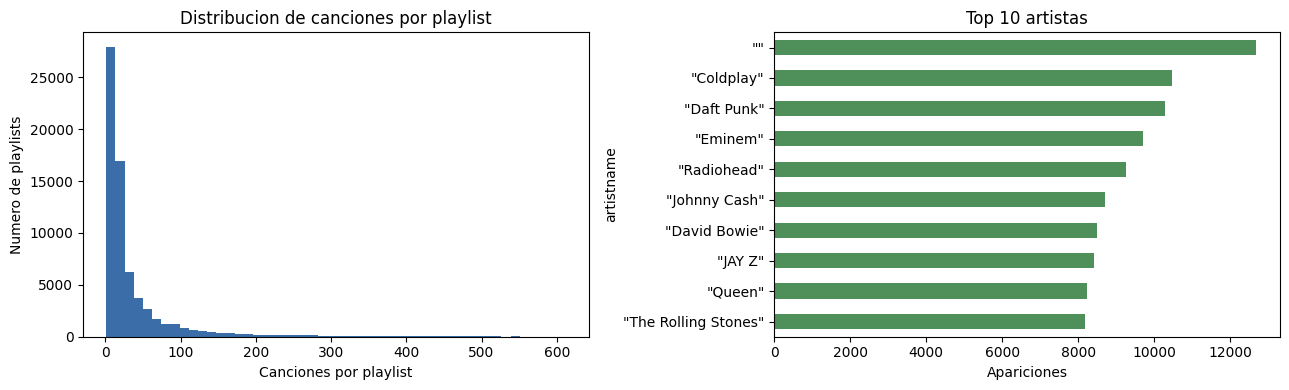

In [4]:
playlist_sizes = music_df.groupby('playlist_id').size()
artist_counts = music_df['artistname'].value_counts()
item_counts = music_df['item_id'].value_counts()

eda_summary = pd.DataFrame({
    'metrica': [
        'filas_muestra', 'usuarios_muestra', 'artistas_muestra', 'tracks_muestra',
        'items_artista_track_muestra', 'playlists_muestra',
        'mediana_canciones_playlist', 'promedio_canciones_playlist'
    ],
    'valor': [
        len(music_df), music_df['user_id'].nunique(), music_df['artistname'].nunique(), music_df['trackname'].nunique(),
        music_df['item_id'].nunique(), music_df['playlist_id'].nunique(),
        playlist_sizes.median(), playlist_sizes.mean()
    ]
})
display(eda_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
playlist_sizes[playlist_sizes <= playlist_sizes.quantile(0.99)].plot(kind='hist', bins=50, ax=axes[0], color='#3b6ea8')
axes[0].set_title('Distribucion de canciones por playlist')
axes[0].set_xlabel('Canciones por playlist')
axes[0].set_ylabel('Numero de playlists')

artist_counts.head(10).sort_values().plot(kind='barh', ax=axes[1], color='#4f8f59')
axes[1].set_title('Top 10 artistas')
axes[1].set_xlabel('Apariciones')
plt.tight_layout()
plt.show()

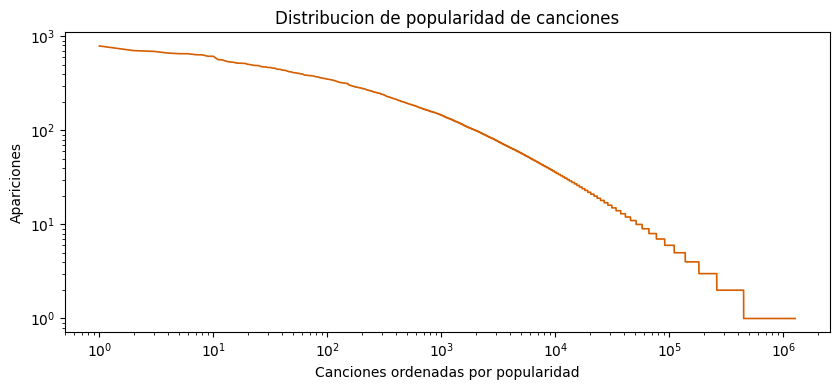

In [5]:
fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(range(1, len(item_counts) + 1), item_counts.values, color='#d55e00', linewidth=1.2)
ax.set_title('Distribucion de popularidad de canciones')
ax.set_xlabel('Canciones ordenadas por popularidad')
ax.set_ylabel('Apariciones')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 4. Split de evaluacion

Se utiliza un protocolo `leave-last-out` por playlist. Para cada playlist con al menos tres canciones, se oculta la ultima cancion como test y se usan las anteriores como contexto.

In [6]:
grouped = music_df.groupby('playlist_id', sort=False).agg(
    item_id=('item_id', list),
    playlistname=('playlistname', 'first')
)
grouped['size'] = grouped['item_id'].str.len()
grouped = grouped[grouped['size'] >= 3]

train_playlists = [items[:-1] for items in grouped['item_id']]
test_items = [items[-1] for items in grouped['item_id']]
playlist_names = grouped['playlistname'].astype(str).tolist()

print('Playlists evaluadas:', len(test_items))
print('Ejemplo train:', train_playlists[0][:5])
print('Ejemplo test:', test_items[0])

Playlists evaluadas: 63851
Ejemplo train: ['"Elvis Costello" - "(The Angels Wanna Wear My) Red Shoes"', '"Tiffany Page" - "7 Years Too Late"', '"Elvis Costello & The Attractions" - "Accidents Will Happen"', '"Elvis Costello" - "Alison"', '"Lissie" - "All Be Okay"']
Ejemplo test: "Cocktail Slippers" - "You Do Run"


## 5. Metricas de ranking

In [7]:
def hit_rate_at_k(recommended, relevant, k):
    return float(relevant in recommended[:k])

def precision_at_k(recommended, relevant, k):
    return float(relevant in recommended[:k]) / k

def average_precision_at_k(recommended, relevant, k):
    for rank, item in enumerate(recommended[:k], start=1):
        if item == relevant:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(recommended, relevant, k):
    for rank, item in enumerate(recommended[:k], start=1):
        if item == relevant:
            return 1.0 / math.log2(rank + 1)
    return 0.0

## 6. Baseline 1: Random

Recomienda canciones aleatorias del catalogo que no esten en la playlist.

In [8]:
train_items = [item for playlist in train_playlists for item in playlist]
catalog = sorted(set(train_items))
rng = random.Random(RANDOM_SEED)

def recommend_random(seen, k=TOP_K):
    recommendations = []
    used = set(seen)
    attempts = 0
    while len(recommendations) < k and attempts < k * 100:
        attempts += 1
        item = rng.choice(catalog)
        if item not in used:
            recommendations.append(item)
            used.add(item)
    return recommendations

print('Catalogo de entrenamiento:', len(catalog))
print(recommend_random(set(train_playlists[0]))[:5])

Catalogo de entrenamiento: 1258737
['"Conflict" - "From Protest to Resistance"', '"Alpha Rev" - "Shelf Life"', '"KCRW" - "Peter Bjorn & John - Young Folks"', '"James Horner" - "Climbing up "Iknimaya - The Path To Heaven""', '"Herbie Hancock" - "Crossings"']


## 7. Baseline 2: Most Popular

Recomienda las canciones mas frecuentes del conjunto de entrenamiento, excluyendo canciones ya presentes en la playlist.

In [9]:
popular_items = [item for item, _ in Counter(train_items).most_common()]

def recommend_most_popular(seen, k=TOP_K):
    recs = []
    for item in popular_items:
        if item not in seen:
            recs.append(item)
            if len(recs) == k:
                break
    return recs

print(popular_items[:5])
print(recommend_most_popular(set(train_playlists[0]))[:5])

['"M83" - "Midnight City"', '"Daft Punk" - "Get Lucky - Radio Edit"', '"Imagine Dragons" - "Radioactive"', '"Of Monsters and Men" - "Little Talks"', '"Lorde" - "Royals"']
['"M83" - "Midnight City"', '"Daft Punk" - "Get Lucky - Radio Edit"', '"Imagine Dragons" - "Radioactive"', '"Of Monsters and Men" - "Little Talks"', '"Lorde" - "Royals"']


## 8. Baseline 3: Playlist Name Popular

Modelo especifico al problema. Usa tokens del nombre de la playlist y recomienda canciones populares en playlists con nombres similares.

In [10]:
def tokenize(text):
    tokens = re.findall(r'[a-z0-9]+', str(text).lower())
    stop = {'the', 'and', 'for', 'con', 'las', 'los', 'una', 'de', 'la', 'el', 'in', 'to', 'of', 'my'}
    return {token for token in tokens if len(token) > 2 and token not in stop}

token_item_counts = defaultdict(Counter)
for playlist, playlist_name in zip(train_playlists, playlist_names):
    for token in tokenize(playlist_name):
        token_item_counts[token].update(playlist[:80])

token_to_items = {token: [item for item, _ in counter.most_common()] for token, counter in token_item_counts.items()}

def recommend_playlist_name(playlist_name, seen, k=TOP_K):
    scores = Counter()
    for token in tokenize(playlist_name):
        for rank, item in enumerate(token_to_items.get(token, [])[:100]):
            if item not in seen:
                scores[item] += 1.0 / (rank + 1)
    recs = [item for item, _ in scores.most_common(k)]
    used = set(seen) | set(recs)
    for item in popular_items:
        if len(recs) == k:
            break
        if item not in used:
            recs.append(item)
            used.add(item)
    return recs

print('Tokens ejemplo:', tokenize(playlist_names[0]))
print(recommend_playlist_name(playlist_names[0], set(train_playlists[0]))[:5])

Tokens ejemplo: {'2010', 'hard', 'rock'}
['"Judas Priest" - "Breaking the Law"', '"Beach House" - "10 Mile Stereo"', '"Foo Fighters" - "Best Of You"', '"Metallica" - "Enter Sandman"', '"The National" - "Bloodbuzz Ohio"']


## 9. Evaluacion de modelos

In [11]:
recommenders = {
    'Random': lambda i, seen: recommend_random(seen),
    'Most Popular': lambda i, seen: recommend_most_popular(seen),
    'Playlist Name Popular': lambda i, seen: recommend_playlist_name(playlist_names[i], seen),
}

rows = []
for model_name, recommender in recommenders.items():
    metrics = defaultdict(float)
    for i, relevant in enumerate(test_items):
        seen = set(train_playlists[i])
        recs = recommender(i, seen)
        metrics['HitRate@10'] += hit_rate_at_k(recs, relevant, TOP_K)
        metrics['Precision@10'] += precision_at_k(recs, relevant, TOP_K)
        metrics['MAP@10'] += average_precision_at_k(recs, relevant, TOP_K)
        metrics['nDCG@10'] += ndcg_at_k(recs, relevant, TOP_K)
    rows.append({'Modelo': model_name, **{k: v / len(test_items) for k, v in metrics.items()}})

results_df = pd.DataFrame(rows)
display(results_df)
results_df.to_csv('resultados_hito1_spotify.csv', index=False)

,Modelo,HitRate@10,Precision@10,MAP@10,nDCG@10
0,Random,0.000000,0.000000,0.000000,0.000000
1,Most Popular,0.001112,0.000111,0.000141,0.000350
2,Playlist Name Popular,0.011871,0.001187,0.004056,0.005835


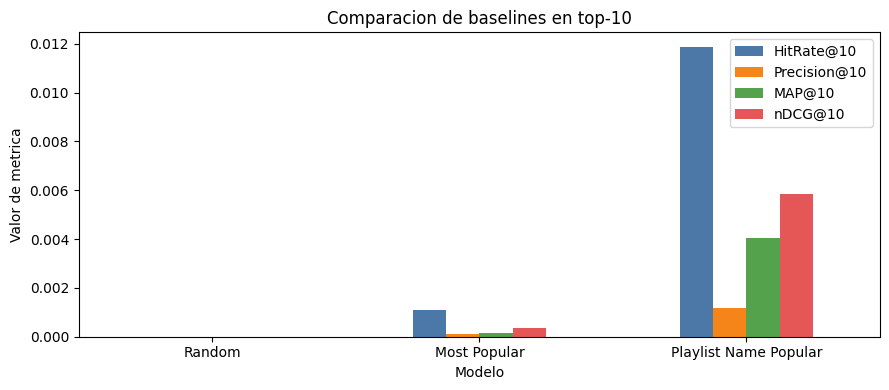

In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
results_df.set_index('Modelo').plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518', '#54a24b', '#e45756'])
ax.set_title('Comparacion de baselines en top-10')
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor de metrica')
ax.tick_params(axis='x', labelrotation=0)
plt.tight_layout()
plt.show()

## 10. Resumen

El baseline `Playlist Name Popular` supera a `Random` y `Most Popular` en todas las metricas evaluadas. Los valores absolutos son bajos porque el catalogo tiene mas de un millon de candidatos y el protocolo exige predecir una cancion especifica oculta por playlist.